In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
train_data = datasets.CIFAR10(root='/data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root='/data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


In [3]:
classes = train_data.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [4]:
len(classes)

10

In [5]:
train = DataLoader(train_data, batch_size=64, shuffle=True)
test = DataLoader(train_data, batch_size=64)

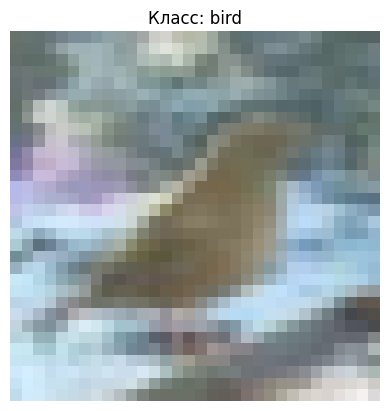

In [6]:
image, label = next(iter(train))
plt.imshow(image[0].permute(1, 2, 0))
plt.title(f'Класс: {classes[label[0]]}')
plt.axis('off')
plt.show()

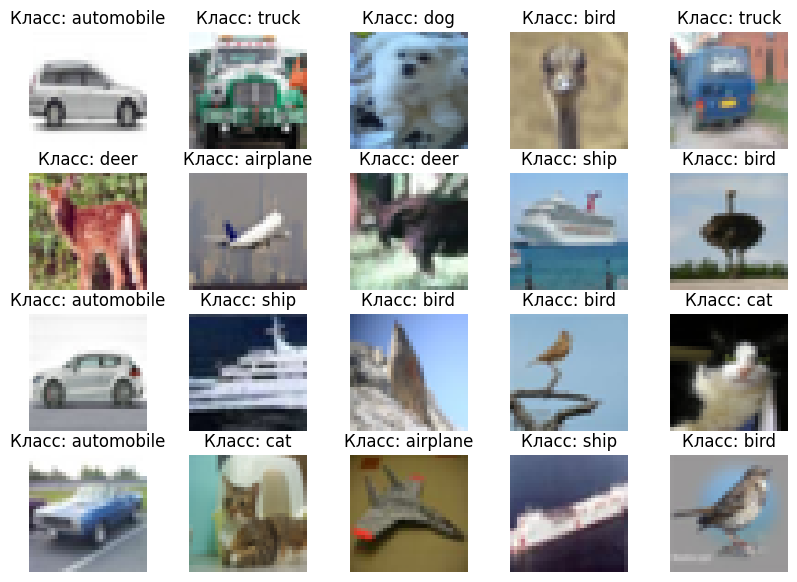

In [7]:
image, label = next(iter(train))
plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(f'Класс: {classes[label[i]]}')
    plt.axis('off')
plt.subplots_adjust(top=0.65)
plt.show()

In [8]:
class CifarmClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, image):
        image = self.first(image)
        image = self.second(image)
        return image

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
model = CifarmClassification().to(device)

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
for epoch in range(50):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f'Эпоха: {epoch + 1}, Потери: {round(total_loss, 2)}%')

Эпоха: 1, Потери: 1175.64%
Эпоха: 2, Потери: 842.22%
Эпоха: 3, Потери: 692.24%
Эпоха: 4, Потери: 594.79%
Эпоха: 5, Потери: 514.83%
Эпоха: 6, Потери: 451.36%
Эпоха: 7, Потери: 387.58%
Эпоха: 8, Потери: 333.67%
Эпоха: 9, Потери: 278.47%
Эпоха: 10, Потери: 235.52%
Эпоха: 11, Потери: 197.32%
Эпоха: 12, Потери: 159.17%
Эпоха: 13, Потери: 135.04%
Эпоха: 14, Потери: 113.44%
Эпоха: 15, Потери: 96.55%
Эпоха: 16, Потери: 86.46%
Эпоха: 17, Потери: 76.04%
Эпоха: 18, Потери: 78.55%
Эпоха: 19, Потери: 73.14%
Эпоха: 20, Потери: 63.19%
Эпоха: 21, Потери: 61.8%
Эпоха: 22, Потери: 60.75%
Эпоха: 23, Потери: 59.17%
Эпоха: 24, Потери: 61.39%
Эпоха: 25, Потери: 54.7%
Эпоха: 26, Потери: 52.42%
Эпоха: 27, Потери: 50.06%
Эпоха: 28, Потери: 45.51%
Эпоха: 29, Потери: 49.71%
Эпоха: 30, Потери: 52.63%
Эпоха: 31, Потери: 50.95%
Эпоха: 32, Потери: 47.53%
Эпоха: 33, Потери: 42.84%
Эпоха: 34, Потери: 44.78%
Эпоха: 35, Потери: 45.66%
Эпоха: 36, Потери: 39.91%
Эпоха: 37, Потери: 50.74%
Эпоха: 38, Потери: 35.99%
Эпоха: 3

In [13]:
from sklearn.metrics import accuracy_score

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        pred = torch.argmax(y_pred, dim=1)

        total += y_batch.size(0)
        correct += (pred == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Тотал модели на тестовых данных: {round(accuracy, 2)}%')


Тотал модели на тестовых данных: 99.32%


In [14]:
torch.save(model.state_dict(), 'model.pth')

In [15]:
class CifarmClassification2(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, image):
        image = self.first(image)
        image = self.second(image)
        return image

In [16]:
model2 = CifarmClassification2().to(device)

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

In [18]:
for epoch in range(50):
    model2.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model2(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f'Эпоха: {epoch + 1}, Потери: {round(total_loss, 2)}%')

Эпоха: 1, Потери: 1218.15%
Эпоха: 2, Потери: 972.79%
Эпоха: 3, Потери: 887.98%
Эпоха: 4, Потери: 828.97%
Эпоха: 5, Потери: 779.21%
Эпоха: 6, Потери: 736.33%
Эпоха: 7, Потери: 706.78%
Эпоха: 8, Потери: 677.04%
Эпоха: 9, Потери: 647.59%
Эпоха: 10, Потери: 619.51%
Эпоха: 11, Потери: 596.19%
Эпоха: 12, Потери: 574.76%
Эпоха: 13, Потери: 553.15%
Эпоха: 14, Потери: 531.29%
Эпоха: 15, Потери: 513.59%
Эпоха: 16, Потери: 496.32%
Эпоха: 17, Потери: 478.17%
Эпоха: 18, Потери: 458.56%
Эпоха: 19, Потери: 441.97%
Эпоха: 20, Потери: 423.35%
Эпоха: 21, Потери: 409.23%
Эпоха: 22, Потери: 390.23%
Эпоха: 23, Потери: 377.31%
Эпоха: 24, Потери: 363.26%
Эпоха: 25, Потери: 349.75%
Эпоха: 26, Потери: 332.27%
Эпоха: 27, Потери: 319.15%
Эпоха: 28, Потери: 307.25%
Эпоха: 29, Потери: 292.54%
Эпоха: 30, Потери: 280.1%
Эпоха: 31, Потери: 272.8%
Эпоха: 32, Потери: 259.23%
Эпоха: 33, Потери: 247.56%
Эпоха: 34, Потери: 237.9%
Эпоха: 35, Потери: 224.15%
Эпоха: 36, Потери: 215.57%
Эпоха: 37, Потери: 206.29%
Эпоха: 38, П

In [19]:
from sklearn.metrics import accuracy_score

model2.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model2(x_batch)
        pred = torch.argmax(y_pred, dim=1)

        total += y_batch.size(0)
        correct += (pred == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Тотал модели на тестовых данных: {round(accuracy, 2)}%')


Тотал модели на тестовых данных: 94.8%


In [20]:
torch.save(model2.state_dict(), 'model2.pth')